# 03 - Modelisation et interpretation

Objectif: comparer les modeles entraines pour predire `failure_within_24h`, choisir le meilleur modele et interpreter les resultats.

## 1. Imports

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid", palette="Set2")
PROJECT_ROOT = Path("..").resolve()
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

## 2. Chargement des resultats

In [2]:
metrics = pd.read_csv(REPORTS_DIR / "model_metrics.csv")
metrics

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,model,cv_f1_mean,cv_roc_auc_mean,cv_average_precision_mean,type
0,0.993762,0.978004,0.941176,0.960000,0.950495,0.999130,0.988600,xgboost,0.905434,0.996240,0.982346,machine_learning
1,0.988355,0.978232,0.863095,0.966667,0.911950,0.996344,0.960052,logistic_regression,0.851622,0.986124,0.942672,machine_learning
2,0.985444,0.972013,0.834302,0.956667,0.891304,0.996049,0.960647,tensorflow_mlp,NaN,NaN,NaN,deep_learning
3,0.986068,0.902335,0.964143,0.806667,0.878403,0.998620,0.978782,random_forest,0.934072,0.996617,0.984012,machine_learning
4,0.985028,0.886223,0.983051,0.773333,0.865672,0.997784,0.974773,gradient_boosting,0.901078,0.993529,0.971386,machine_learning


In [3]:
best_model = metrics.sort_values("f1", ascending=False).iloc[0]
best_model

accuracy                             0.993762
balanced_accuracy                    0.978004
precision                            0.941176
recall                                   0.96
f1                                   0.950495
roc_auc                               0.99913
average_precision                      0.9886
model                                 xgboost
cv_f1_mean                           0.905434
cv_roc_auc_mean                       0.99624
cv_average_precision_mean            0.982346
type                         machine_learning
Name: 0, dtype: object

## 3. Comparaison quantitative

Les metriques les plus importantes pour ce projet sont:

- `recall`: capacite a detecter les pannes reelles;
- `precision`: qualite des alertes;
- `f1`: compromis entre precision et recall;
- `roc_auc` et `average_precision`: qualite globale du classement des risques.

Dans un contexte industriel, le recall est tres important, car une panne non detectee peut provoquer un arret non planifie.

In [4]:
display_cols = ["model", "type", "accuracy", "precision", "recall", "f1", "roc_auc", "average_precision", "cv_f1_mean"]
metrics[display_cols].sort_values("f1", ascending=False)

,model,type,accuracy,precision,recall,f1,roc_auc,average_precision,cv_f1_mean
0,xgboost,machine_learning,0.993762,0.941176,0.960000,0.950495,0.999130,0.988600,0.905434
1,logistic_regression,machine_learning,0.988355,0.863095,0.966667,0.911950,0.996344,0.960052,0.851622
2,tensorflow_mlp,deep_learning,0.985444,0.834302,0.956667,0.891304,0.996049,0.960647,NaN
3,random_forest,machine_learning,0.986068,0.964143,0.806667,0.878403,0.998620,0.978782,0.934072
4,gradient_boosting,machine_learning,0.985028,0.983051,0.773333,0.865672,0.997784,0.974773,0.901078


<Figure size 1200x600 with 0 Axes>

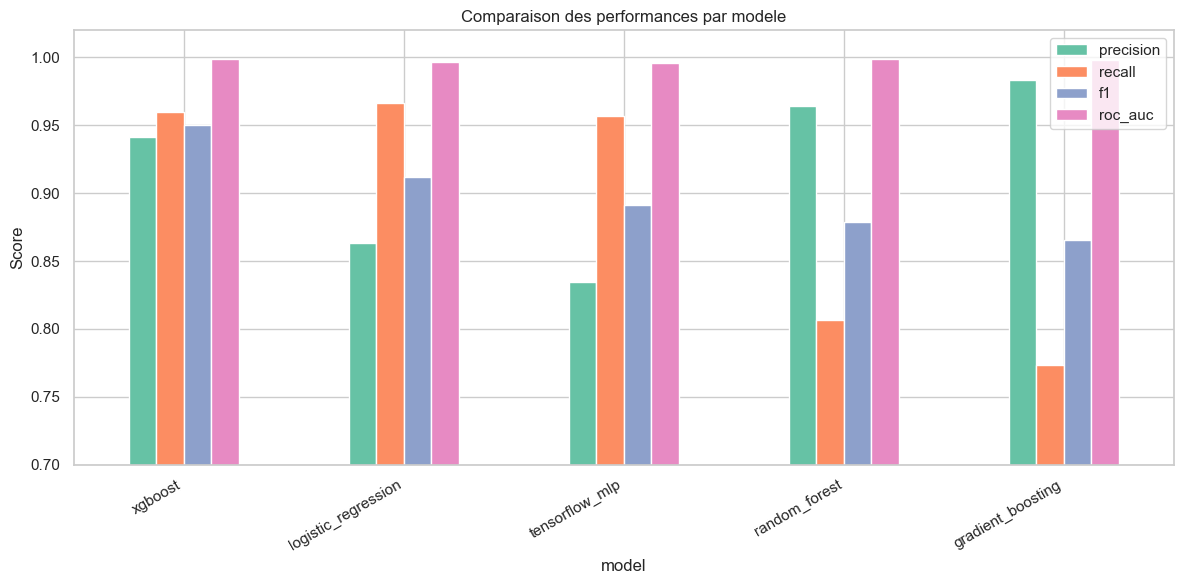

In [5]:
plot_metrics = metrics.set_index("model")[["precision", "recall", "f1", "roc_auc"]]

plt.figure(figsize=(12, 6))
plot_metrics.plot(kind="bar", figsize=(12, 6))
plt.title("Comparaison des performances par modele")
plt.ylabel("Score")
plt.ylim(0.7, 1.02)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Choix du meilleur modele

Le modele retenu est **XGBoost**. Il obtient le meilleur F1-score, avec un tres bon recall et une precision elevee.

Cela signifie qu'il detecte la majorite des pannes tout en limitant les fausses alertes. Ce compromis est adapte a la maintenance predictive.

In [6]:
print(f"Meilleur modele: {best_model['model']}")
print(f"F1-score: {best_model['f1']:.4f}")
print(f"Recall: {best_model['recall']:.4f}")
print(f"Precision: {best_model['precision']:.4f}")
print(f"ROC AUC: {best_model['roc_auc']:.4f}")

Meilleur modele: xgboost
F1-score: 0.9505
Recall: 0.9600
Precision: 0.9412
ROC AUC: 0.9991


## 5. Rapport de classification

In [7]:
with open(REPORTS_DIR / "classification_report.json", encoding="utf-8") as file:
    classification_report = json.load(file)

pd.DataFrame(classification_report).T

,precision,recall,f1-score,support
0,0.997335,0.996008,0.996671,4509.000000
1,0.941176,0.960000,0.950495,300.000000
accuracy,0.993762,0.993762,0.993762,0.993762
macro avg,0.969256,0.978004,0.973583,4809.000000
weighted avg,0.993832,0.993762,0.993791,4809.000000


Pour la classe `1`, c'est-a-dire les pannes dans les 24h, XGBoost atteint un recall de 0.96. Le modele detecte donc 96% des cas de panne du jeu de test.

## 6. Matrice de confusion et courbes

confusion_matrix.png


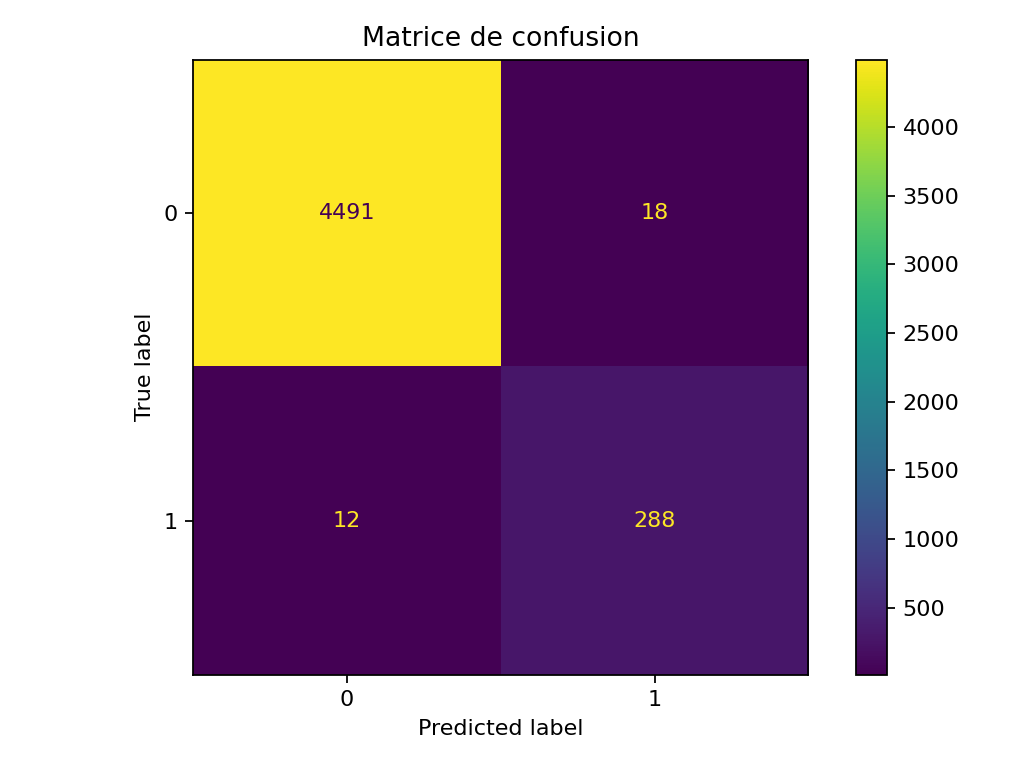

roc_curve.png


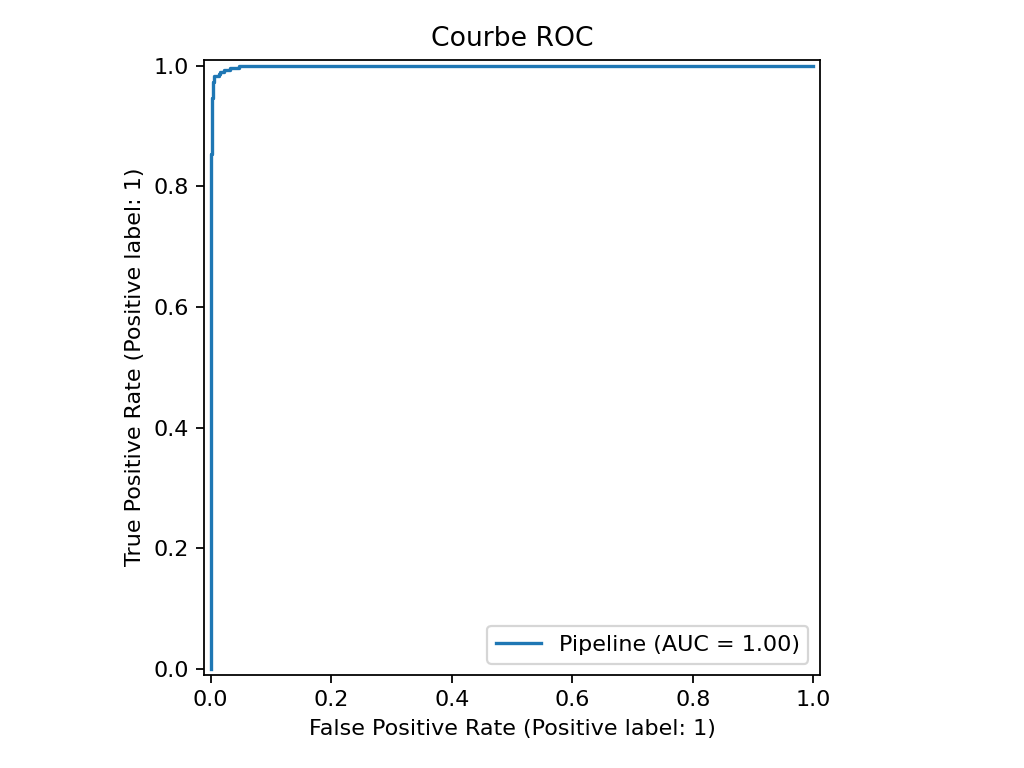

precision_recall_curve.png


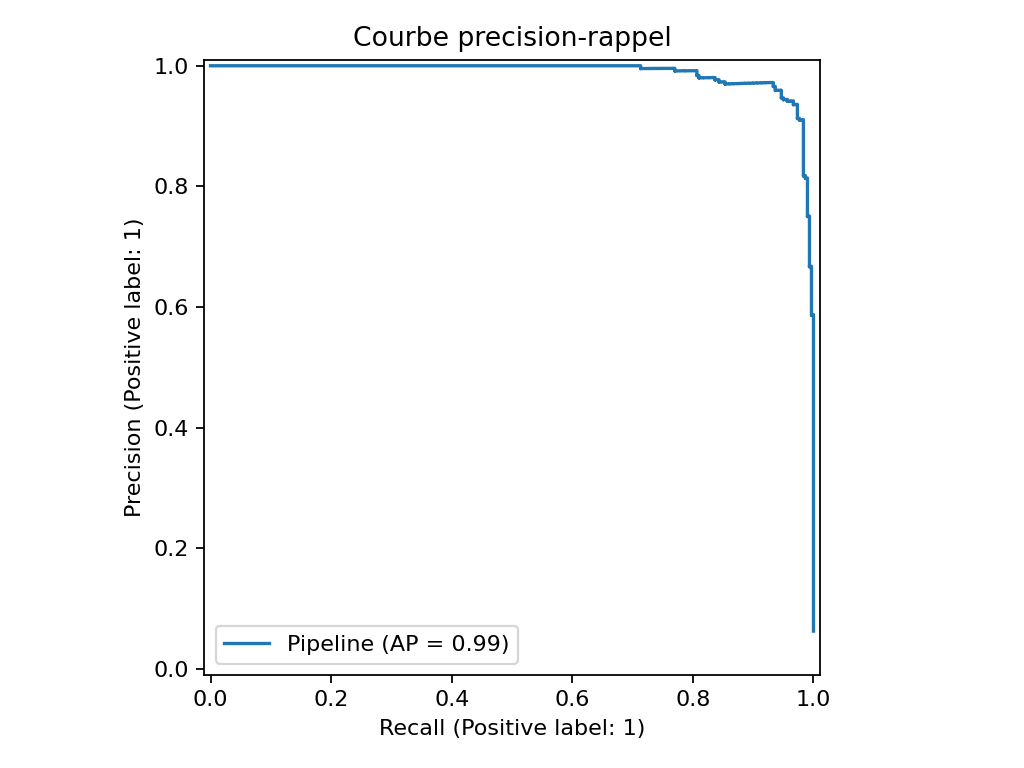

In [8]:
for figure_name in ["confusion_matrix.png", "roc_curve.png", "precision_recall_curve.png"]:
    print(figure_name)
    display(Image(filename=str(FIGURES_DIR / figure_name)))

Lecture de la matrice de confusion du modele XGBoost:

- 288 pannes detectees correctement;
- 12 pannes manquees;
- 18 fausses alertes;
- 4491 observations sans panne correctement classees.

Les faux negatifs sont les erreurs les plus critiques, car ils correspondent a des pannes non anticipees.

## 7. Importance des variables

In [9]:
feature_importance = pd.read_csv(REPORTS_DIR / "feature_importance.csv")
feature_importance.head(15)

,feature,importance_mean,importance_std
0,temperature_motor_roll_mean_6,0.662699,0.007583
1,rpm_roll_mean_6,0.516358,0.011011
2,vibration_rms_roll_mean_6,0.112109,0.006391
3,pressure_level_roll_mean_6,0.070799,0.008203
4,rpm,0.062237,0.007918
5,current_phase_avg_roll_mean_6,0.022879,0.005973
6,hours_since_maintenance,0.020530,0.003019
7,vibration_rms,0.016925,0.006371
8,temperature_motor,0.011440,0.007261
9,current_phase_avg_roll_std_6,0.005964,0.003288


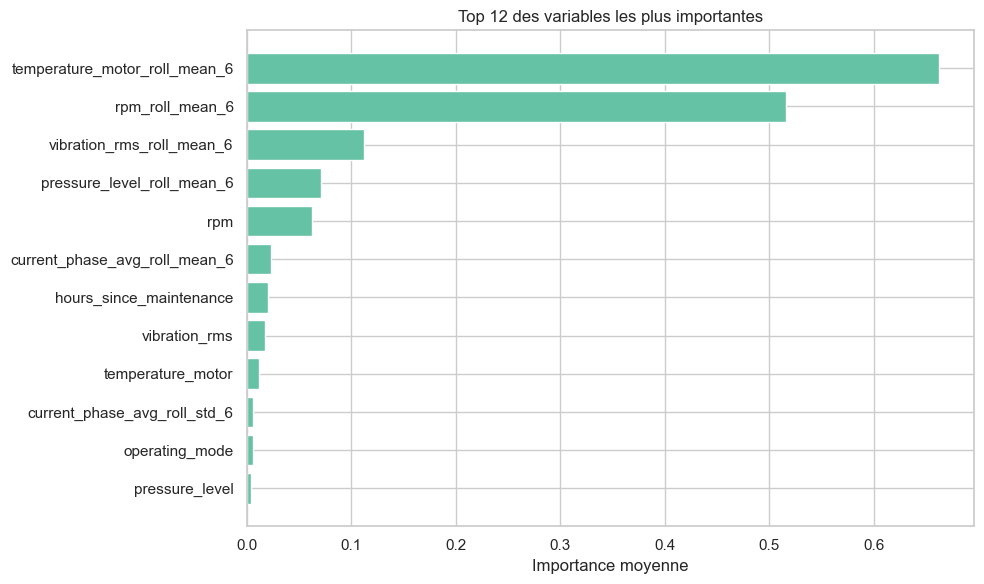

In [10]:
top_features = feature_importance.head(12).sort_values("importance_mean")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.title("Top 12 des variables les plus importantes")
plt.xlabel("Importance moyenne")
plt.tight_layout()
plt.show()

Les variables les plus importantes sont principalement des moyennes mobiles de capteurs. Cela montre que les tendances recentes sont tres informatives pour anticiper une panne.

Les signaux principaux sont la temperature moteur moyenne recente, le regime moteur moyen recent, la vibration moyenne recente et la pression moyenne recente.

## 8. Conclusion

XGBoost est le meilleur modele pour ce projet. Il combine:

- un excellent F1-score;
- un recall eleve, important pour ne pas manquer les pannes;
- une precision elevee, utile pour limiter les interventions inutiles;
- une interpretation possible grace a l'importance des variables.

Ce modele peut etre utilise dans le dashboard pour prioriser les machines a inspecter.